# Three-color SWIM output-selection strategies

This notebook compares four post-hoc scalar outputs derived from the same saved per-color circuit-level SWIM values: the ordinary decoder's selected-color value, minimum, maximum, and arithmetic mean. It loads existing shots and never runs the physical experiment. Every strategy is evaluated against the **same ordinary hard-decoder logical-error labels** using the established distribution, conditional-LER, and post-selection analyses.

Only the selected-color rule is the implemented decoder output. Minimum, maximum, and mean are empirical analysis proposals. This notebook does not establish a full-decoder gap, LLR, posterior calibration, optimal aggregation rule, or change to the hard decoder.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown
from color_code_softoutput.analysis.circuit_level import CircuitLevelDataset
from color_code_softoutput.analysis.swim_selection import (
    STRATEGIES, STRATEGY_LABELS, SCORE_LABELS,
    SwimSelectionDataset, analyze_swim_selection_strategies,
)

## Load an existing experiment

By default, load the most recent completed circuit-memory run. Set `existing_run` to a particular timestamped directory for a stable analysis target. No simulation entry point is imported.

In [2]:
workspace = Path.cwd()
if not (workspace / "results").is_dir():
    workspace = workspace.parent
existing_run = None  # Example: workspace / "results/20260916_212315_582740_circuit_level_memory_test"
if existing_run is None:
    candidates = []
    for metadata_path in sorted(workspace.glob("results/*_circuit_level_memory_test/metadata.json")):
        metadata = json.loads(metadata_path.read_text())
        if metadata.get("status") in {"sampling_complete", "complete"}:
            candidates.append(metadata_path.parent)
    if not candidates:
        raise FileNotFoundError("No completed circuit-level run was found")
    run_directory = candidates[-1]
else:
    run_directory = Path(existing_run)
dataset = CircuitLevelDataset(run_directory)
print("Loaded:", run_directory)
print("Shots:", dataset.metadata["completed_shots"])
print("Hard-output invariance:", dataset.metadata["hard_output_invariance"])
dataset.available_values()

Loaded: /home/quantum_teresheys/workspace/color_code_softoutput/results/20260916_212315_582740_circuit_level_memory_test
Shots: 300000
Hard-output invariance: {'checked_shots': 300000, 'mismatches': 0, 'scope': 'prediction, ordinary weight, selected color, correction and failure label'}


{'distance': [3, 5, 7], 'physical_error_rate': [0.003]}

## Analysis controls

`round_digits=None` preserves the stored-score behavior. An integer rounds each derived scalar before grouping, fitting, or thresholding; post-selection keeps whole ties after this optional rounding. Raw Parquet values remain unchanged.

In [3]:
round_digits = None
signed_logical_errors = False
normalize_frequency = False
bins = "auto"
analysis_root = (workspace / "implementation_artifacts/circuit_level/swim_output_selection"
                 / run_directory.name)
strategy_definitions = pd.DataFrame([
    {"strategy": "selected_color", "definition": "phi of ordinary_selected_color",
     "decoder_output": True},
    {"strategy": "minimum", "definition": "min(phi_r, phi_g, phi_b)",
     "decoder_output": False},
    {"strategy": "maximum", "definition": "max(phi_r, phi_g, phi_b)",
     "decoder_output": False},
    {"strategy": "mean", "definition": "(phi_r + phi_g + phi_b) / 3",
     "decoder_output": False},
])
display(strategy_definitions)
print("Artifacts:", analysis_root)

,strategy,definition,decoder_output
0,selected_color,phi of ordinary_selected_color,True
1,minimum,"min(phi_r, phi_g, phi_b)",False
2,maximum,"max(phi_r, phi_g, phi_b)",False
3,mean,(phi_r + phi_g + phi_b) / 3,False


Artifacts: /home/quantum_teresheys/workspace/color_code_softoutput/implementation_artifacts/circuit_level/swim_output_selection/20260916_212315_582740_circuit_level_memory_test


## Compute the four saved-data analysis views

Each strategy gets a separate directory containing three PDF/PNG plot pairs and the underlying Parquet count/rate tables. Wilson intervals are shown as semi-transparent shaded regions.

{'selected_color': '/home/quantum_teresheys/workspace/color_code_softoutput/implementation_artifacts/circuit_level/swim_output_selection/20260916_212315_582740_circuit_level_memory_test/selected_color',
 'minimum': '/home/quantum_teresheys/workspace/color_code_softoutput/implementation_artifacts/circuit_level/swim_output_selection/20260916_212315_582740_circuit_level_memory_test/minimum',
 'maximum': '/home/quantum_teresheys/workspace/color_code_softoutput/implementation_artifacts/circuit_level/swim_output_selection/20260916_212315_582740_circuit_level_memory_test/maximum',
 'mean': '/home/quantum_teresheys/workspace/color_code_softoutput/implementation_artifacts/circuit_level/swim_output_selection/20260916_212315_582740_circuit_level_memory_test/mean'}

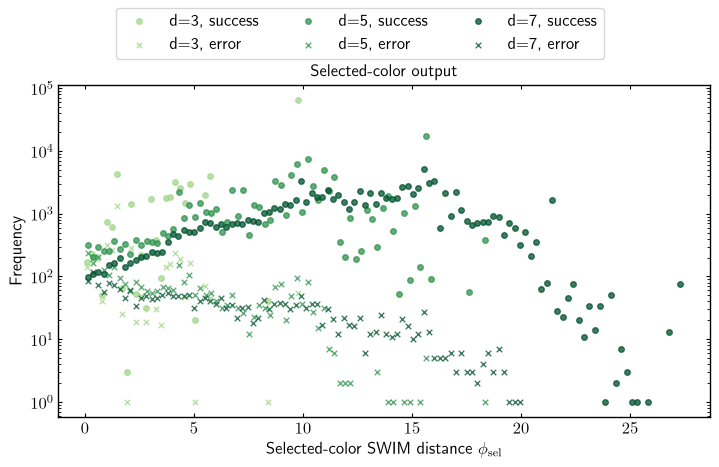

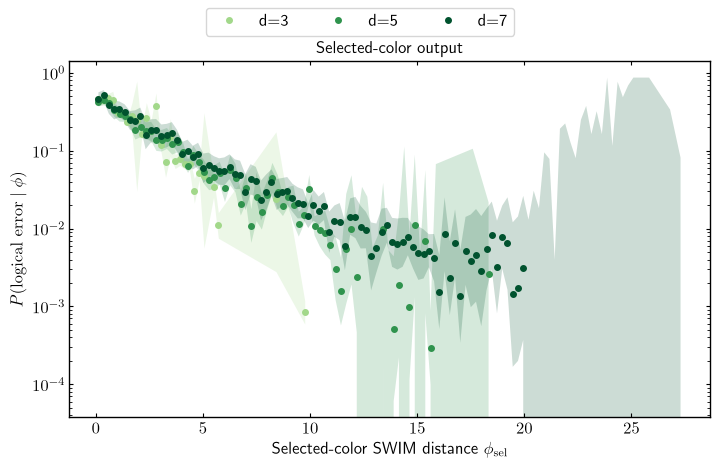

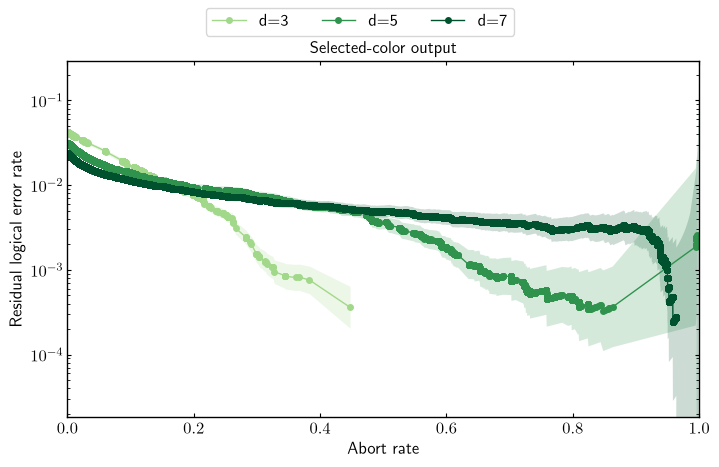

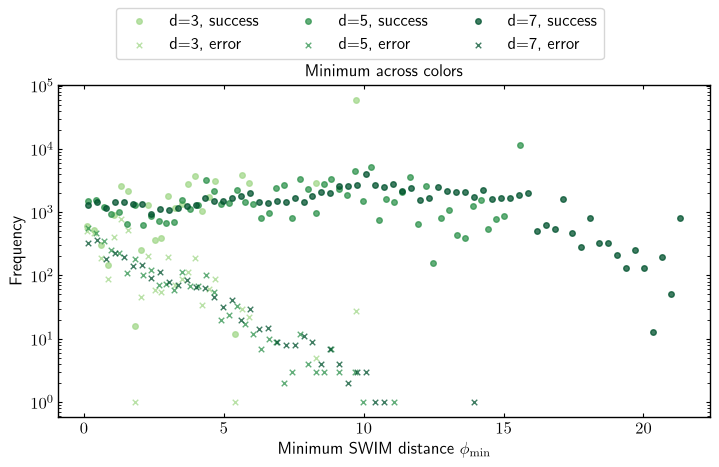

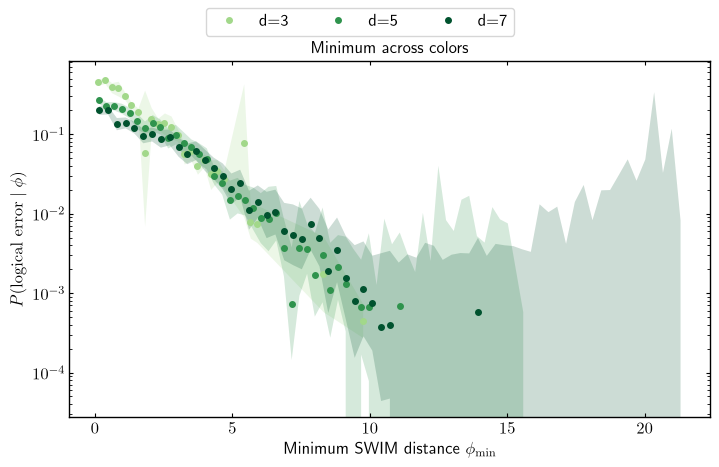

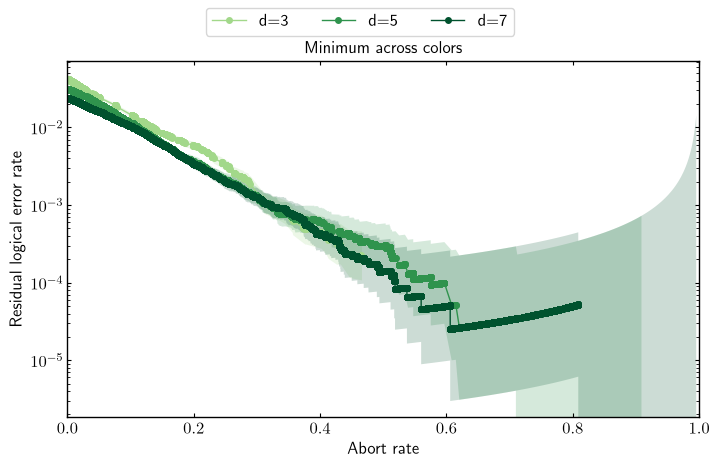

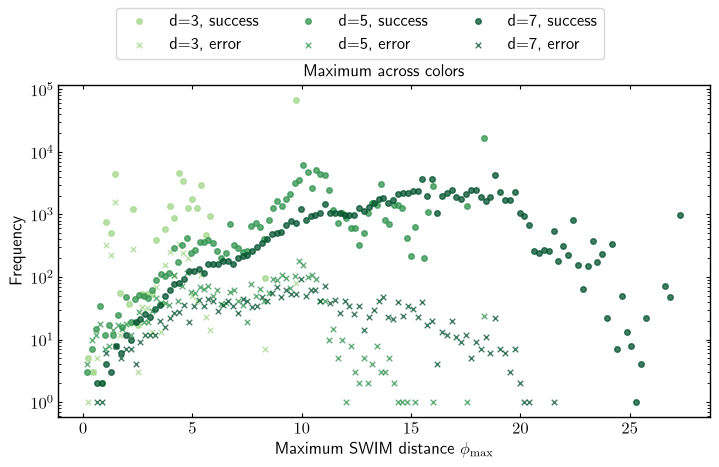

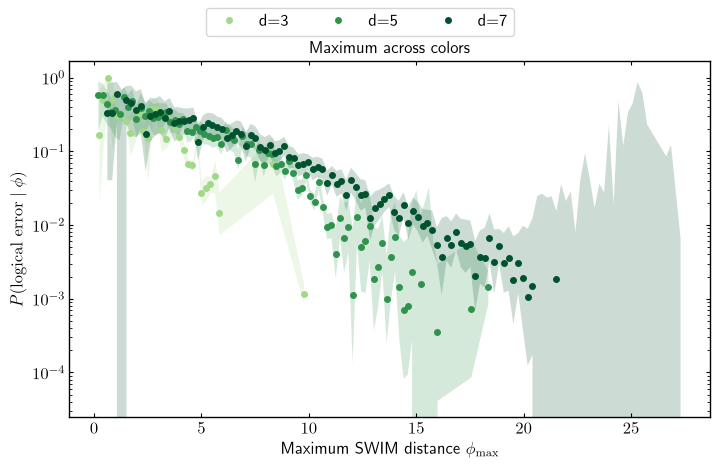

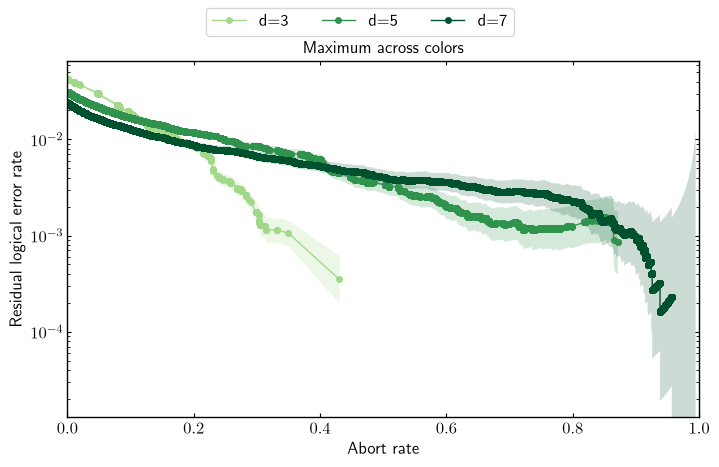

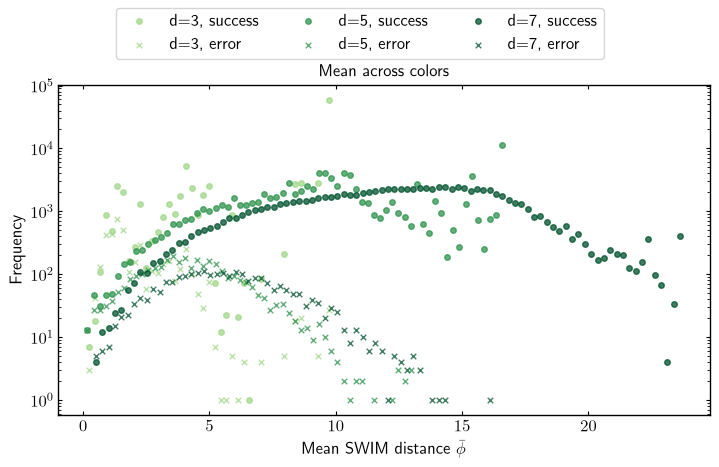

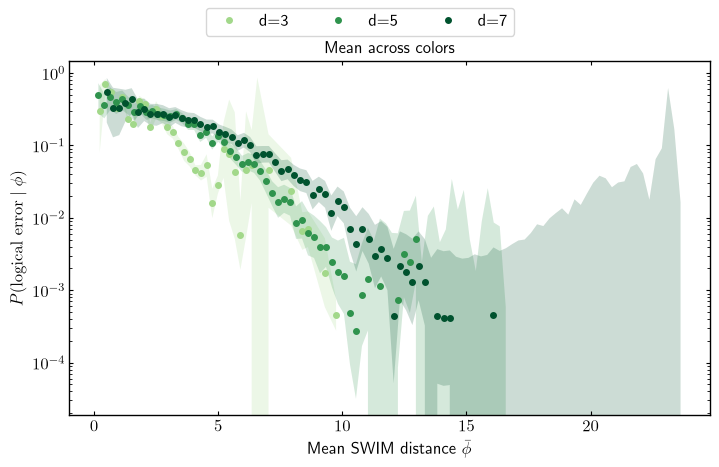

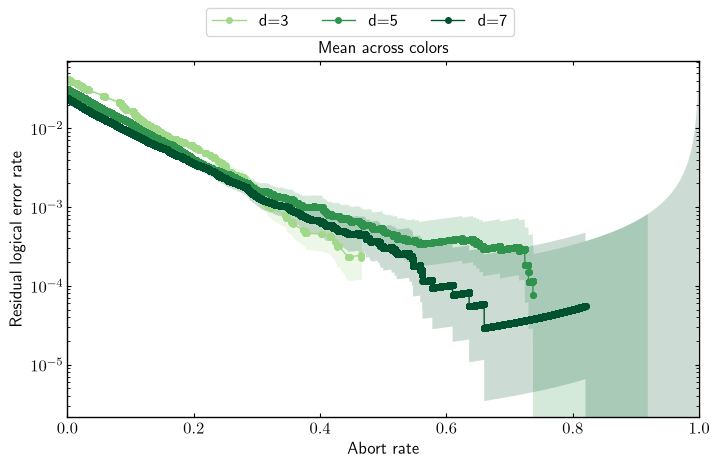

In [4]:
analyses = analyze_swim_selection_strategies(
    dataset, output_directory=analysis_root, round_digits=round_digits,
    signed_logical_errors=signed_logical_errors,
    normalize_frequency=normalize_frequency, bins=bins,
)
{strategy: str(result.directory) for strategy, result in analyses.items()}

## 1. Distribution

Success (`o`) and ordinary logical error (`x`) markers use the existing conventions. Each strategy is plotted separately so its score scale and outcome overlap remain visible.

### Selected-color output

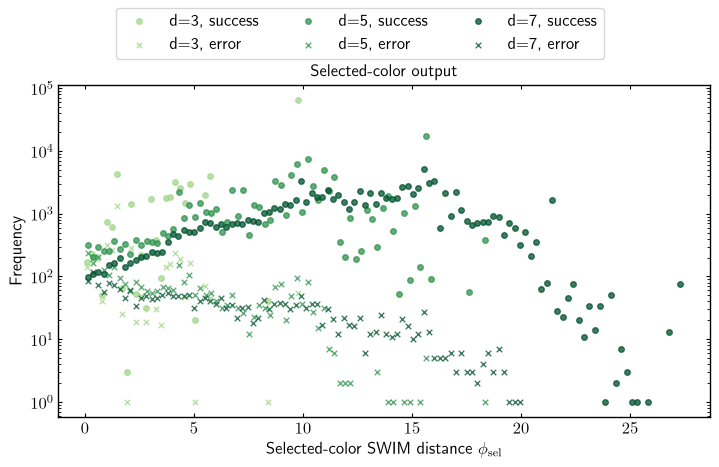

### Minimum across colors

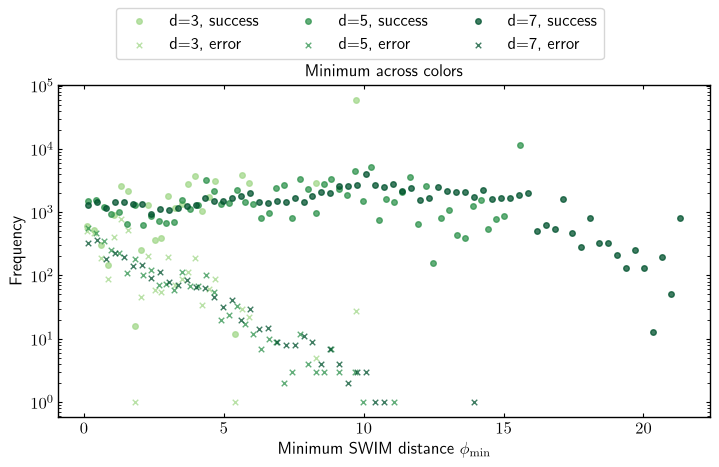

### Maximum across colors

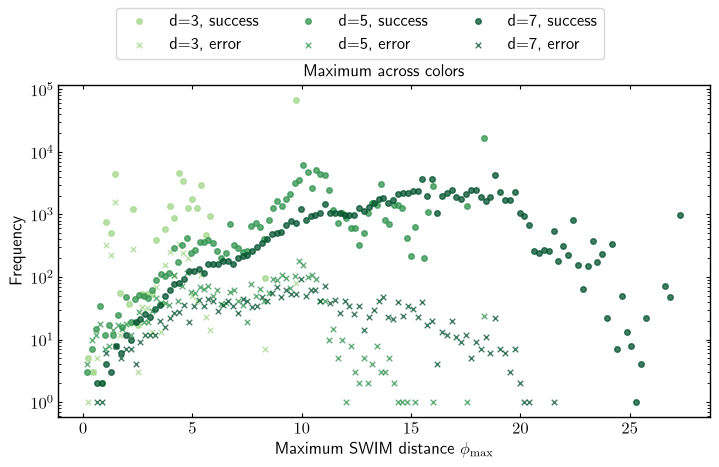

### Mean across colors

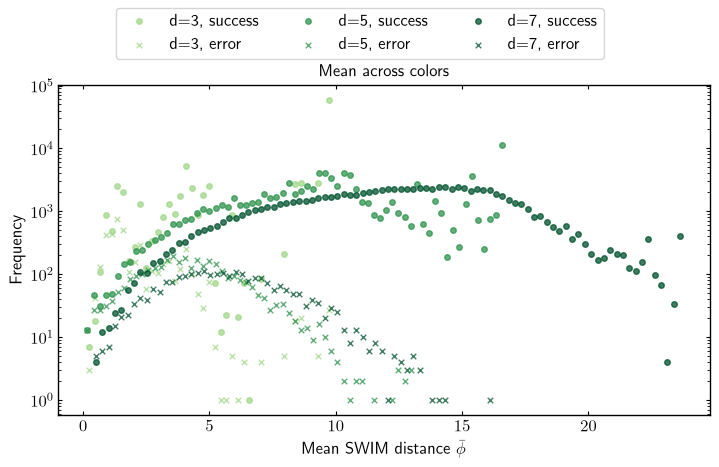

In [5]:
for strategy in STRATEGIES:
    display(Markdown(f"### {STRATEGY_LABELS[strategy]}"))
    display(analyses[strategy].distribution_figure)
    plt.close(analyses[strategy].distribution_figure)

## 2. Conditional logical error rate

Every panel uses the ordinary decoder's logical-error label. Points are empirical grouped rates; shaded regions are 99% Wilson intervals. No logistic calibration curve is overlaid.

In [ ]:
for strategy in STRATEGIES:
    display(Markdown(f"### {STRATEGY_LABELS[strategy]}"))
    display(analyses[strategy].conditional_figure)
    plt.close(analyses[strategy].conditional_figure)

## 3. Post-selection performance

For each strategy, retain derived scores greater than or equal to each threshold and plot residual ordinary LER against abort rate. Thresholds use every exact derived value, or every exact rounded value when `round_digits` is set; ties stay together.

In [ ]:
for strategy in STRATEGIES:
    display(Markdown(f"### {STRATEGY_LABELS[strategy]}"))
    display(analyses[strategy].postselection_figure)
    plt.close(analyses[strategy].postselection_figure)

## Numerical tables and score summary

The plots are the primary like-for-like comparison. The summary below reports only descriptive score statistics; it does not rank the strategies or reinterpret them as calibrated confidence.

In [ ]:
summary_rows = []
for strategy in STRATEGIES:
    view = SwimSelectionDataset(dataset, strategy, analysis_root / strategy)
    for distance in dataset.available_values()["distance"]:
        rows = view.metric_rows("selected_swim_distance", distance=distance,
                                physical_error_rate=dataset.available_values()["physical_error_rate"][0])
        summary_rows.append({
            "strategy": strategy, "distance": distance, "shots": len(rows),
            "ordinary_failures": int(rows.ordinary_logical_error.sum()),
            "score_mean": rows.selected_swim_distance.mean(),
            "score_median": rows.selected_swim_distance.median(),
            "score_min": rows.selected_swim_distance.min(),
            "score_max": rows.selected_swim_distance.max(),
        })
strategy_summary = pd.DataFrame(summary_rows)
strategy_summary.to_parquet(analysis_root / "strategy_score_summary.parquet", index=False)
strategy_summary

In [ ]:
artifact_index = pd.DataFrame([
    {"strategy": strategy, "directory": str(result.directory),
     "distribution_rows": len(result.distribution_table),
     "conditional_rows": len(result.conditional_table),
     "postselection_rows": len(result.postselection_table)}
    for strategy, result in analyses.items()
])
artifact_index.to_parquet(analysis_root / "artifact_index.parquet", index=False)
artifact_index

All four strategies reuse the same physical shots, per-color SWIM values, hard prediction, and ordinary logical-error labels. The analysis does not alter the decoder or source data. The current growth convention remains uncertified. Any claim that one rule is generally optimal requires a separately designed statistical and theoretical study.